# Stored restriction maps visualisations

## 1. Import an Functions

In [13]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy import stats
from tkinter import font
import scipy.sparse as sp

In [14]:
def fbc(L):
    l=L.shape[0]
    B=L.copy()
    for i in range(l):
        B[i,i]=np.sum(np.abs(L[i,:]))-np.abs(L[i,i])

    F=L-B
    return B , F

In [15]:
def matrix_abs(A):
    """
    Matrix absolute value: |A| = U Σ U^T, where A = U Σ V^T is the SVD.
    This is the "left" polar factor — it has the same singular values as A
    but is symmetric positive semi-definite.
    """
    U, S, Vt = np.linalg.svd(A)
    return U @ np.diag(S) @ U.T


def fbc_block(L, n, d):
    """
    Forman-Bochner decomposition for a block sheaf Laplacian.

    L : (n*d) x (n*d) dense numpy array — the full sheaf Laplacian
    n : number of graph nodes
    d : stalk dimension

    Returns (B, F) where:
      B_{u,v} = L_{u,v}                      for u ≠ v  (lateral blocks unchanged)
      B_{u,u} = sum_{w ≠ u} |L_{u,w}|        (diagonal = sum of matrix abs of row blocks)
      F = L - B
    """
    B = L.copy()

    for u in range(n):
        row_sum = np.zeros((d, d))
        for w in range(n):
            if w == u:
                continue
            block = L[u*d:(u+1)*d, w*d:(w+1)*d]
            # Zero blocks (non-neighbours) contribute nothing: |0| = 0.
            # No need to explicitly check for neighbours.
            if np.any(block != 0):          # skip the SVD for exact zeros (speed)
                row_sum += matrix_abs(block)

        B[u*d:(u+1)*d, u*d:(u+1)*d] = row_sum

    F = L - B
    return B, F


## 2. Data Manipulation: Load Laplacian and compute curvatures 

In [16]:
# Load maps and Laplacians
stalk_dim = 2
hidden_channels = 16
dataset = "cornell"
layers = 2
epochs = 500
mode = "General"
#num_nodes = 22662 # Roman Empire
num_nodes = 183 # Cornell

#MAPS = []
LAPLACIANS = []
for layer in range(layers):
    #map_path = f"../results/maps/{dataset}/stalk_dim-{stalk_dim}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/{mode}Sheaf_{dataset}_layer{layer}_fold3_seed43.pt"
    lap_path = f"../results/laplacians/{dataset}/stalk_dim-{stalk_dim}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/{mode}Sheaf_{dataset}_layer{layer}_fold3_seed43.pt"
    #MAPS.append(torch.load(map_path))
    LAPLACIANS.append(torch.load(lap_path))

# Maps: shape [num_edges, 2 + d^2], first two cols are source/target
#d = stalk_dim
#map_cols = [f"a{i+1}{j+1}" for i in range(d) for j in range(d)]
#DF = []
#for maps_tensor in MAPS:
    #df = pd.DataFrame(maps_tensor[:, 2:].numpy(), columns=map_cols)
    #df.insert(0, "source", maps_tensor[:, 0].long().numpy())
    #df.insert(1, "target", maps_tensor[:, 1].long().numpy())
    #DF.append(df)


C:\Users\Utente\AppData\Local\Temp\ipykernel_15424\2696840052.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  LAPLACIANS.append(torch.load(lap_path))


In [22]:
n, d = num_nodes, stalk_dim

L_LIST = []
ev_list = []
e_list  = []
F_diag_list = []   # list of [n, d, d] arrays — one d×d block per node per layer

def get_block(L, u, v, d):
    return L[u*d:(u+1)*d, v*d:(v+1)*d]

for lap in LAPLACIANS:
    # Build the full nd×nd Laplacian from COO format
    row_idx = lap[0].long().numpy()
    col_idx = lap[1].long().numpy()
    values  = lap[2].numpy()
    L = sp.coo_matrix((values, (row_idx, col_idx)), shape=(n*d, n*d)).toarray()

    # Forman-Bochner decomposition (block version)
    B, F = fbc_block(L, n, d)

    # Eigendecomposition of the full nd×nd Laplacian
    e, ev = np.linalg.eigh(L)

    # Extract diagonal blocks of F: one d×d matrix per node
    F_diags = np.stack([get_block(F, u, u, d) for u in range(n)])  # shape [n, d, d]

    L_LIST.append(L)
    e_list.append(e)
    ev_list.append(ev)
    F_diag_list.append(F_diags)

curv_eigs = [np.linalg.eigvalsh(F_diag_list[layer]) for layer in range(layers)]  # [layers][n, d]


In [23]:
lap = LAPLACIANS[0]
row_idx = lap[0].long().numpy()
col_idx = lap[1].long().numpy()

# decode nd-space indices back to node numbers
edges = set()
for r, c in zip(row_idx, col_idx):
    u, v = int(r) // d, int(c) // d
    if u != v:
        edges.add((min(u, v), max(u, v)))

G = nx.Graph()
G.add_nodes_from(range(n))   # nodes 0..n-1, same order as Laplacian
G.add_edges_from(sorted(edges))
nodelist = list(range(n))    # already sorted, coherent with L_LIST

L_top_un = nx.laplacian_matrix(G, nodelist=nodelist).toarray().astype(float)
d0 = np.diag(L_top_un) + 1
D_inv_sqrt = np.diag(1.0 / np.sqrt(d0))
L_top = D_inv_sqrt @ L_top_un @ D_inv_sqrt

B_top, F_top = fbc(L_top)
f0_top = np.diag(F_top)
e_top, ev_top = np.linalg.eigh(L_top)

print(G.number_of_nodes(), G.number_of_edges())  # should be 2708, 5429


183 277


## 3. Visualizations: Plot of curvatures, and then spectral quantities 

183 183 183


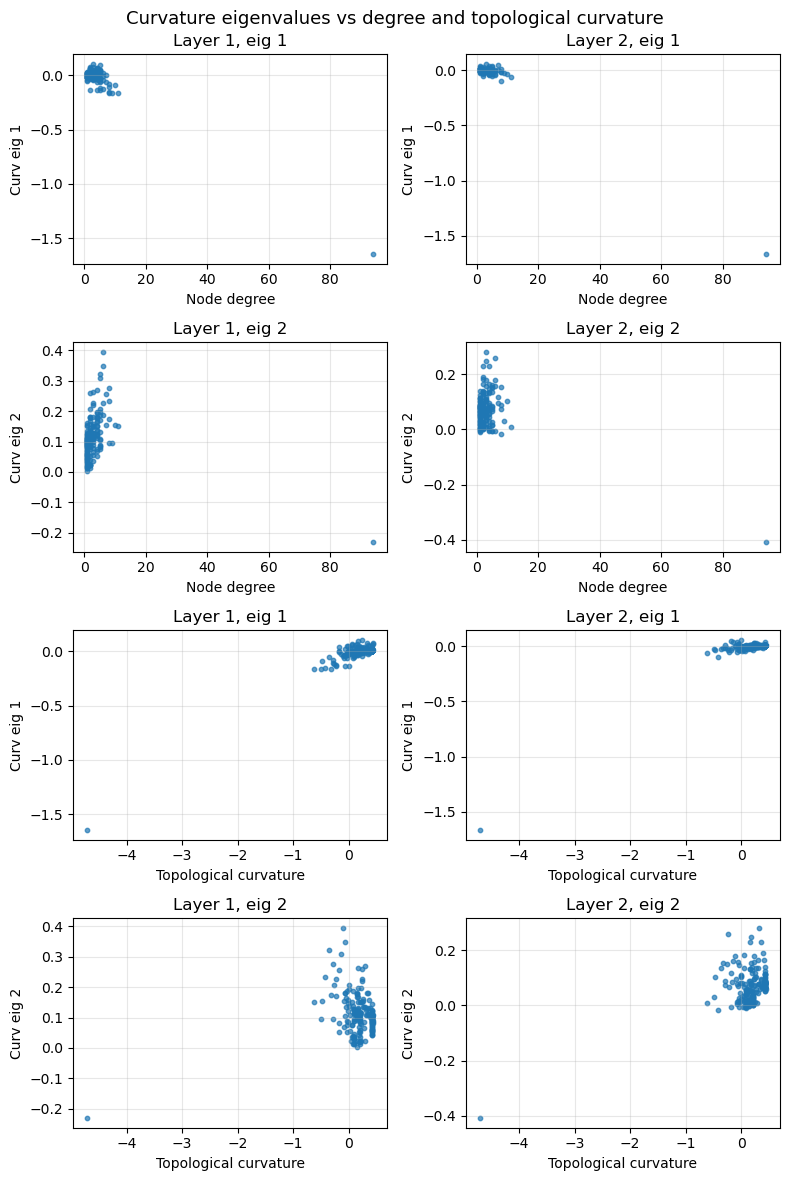

In [24]:
node_degrees = np.array([G.degree(u) for u in nodelist])
print(len(node_degrees), len(f0_top), len(curv_eigs[0][:,0]))
fig, axes = plt.subplots(2*d, layers, figsize=(4*layers, 3*2*d))
if layers == 1: axes = axes.reshape(-1, 1)

for k in range(d):
    for layer in range(layers):
        axes[k, layer].scatter(node_degrees, curv_eigs[layer][:, k], s=10, alpha=0.7)
        axes[k, layer].set_xlabel("Node degree")
        axes[k, layer].set_ylabel(f"Curv eig {k+1}")
        axes[k, layer].set_title(f"Layer {layer+1}, eig {k+1}")
        axes[k, layer].grid(alpha=0.3)

        axes[d+k, layer].scatter(f0_top, curv_eigs[layer][:, k], s=10, alpha=0.7)
        axes[d+k, layer].set_xlabel("Topological curvature")
        axes[d+k, layer].set_ylabel(f"Curv eig {k+1}")
        axes[d+k, layer].set_title(f"Layer {layer+1}, eig {k+1}")
        axes[d+k, layer].grid(alpha=0.3)

fig.suptitle("Curvature eigenvalues vs degree and topological curvature", fontsize=13)
fig.tight_layout()
#fig.savefig(f"../results/images/{dataset}_curv_scatter.pdf")


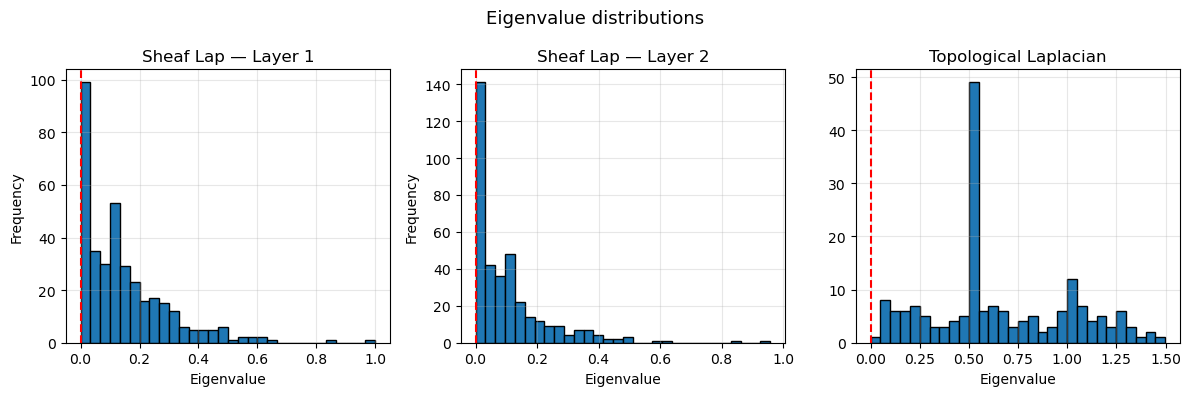

In [25]:
fig, axes = plt.subplots(1, layers+1, figsize=(4*(layers+1), 4))
for layer in range(layers):
    axes[layer].hist(e_list[layer], bins=30, edgecolor="black")
    axes[layer].axvline(0, color="red", linestyle="--")
    axes[layer].set_title(f"Sheaf Lap — Layer {layer+1}")
    axes[layer].set_xlabel("Eigenvalue")
    axes[layer].set_ylabel("Frequency")
    axes[layer].grid(alpha=0.3)
axes[layers].hist(e_top, bins=30, edgecolor="black")
axes[layers].axvline(0, color="red", linestyle="--")
axes[layers].set_title("Topological Laplacian")
axes[layers].set_xlabel("Eigenvalue")
axes[layers].grid(alpha=0.3)
fig.suptitle("Eigenvalue distributions", fontsize=13)
fig.tight_layout()
#fig.savefig(f"../results/images/{dataset}_eigenvalue_distributions.pdf")


## 4. Plotting of the Graphs

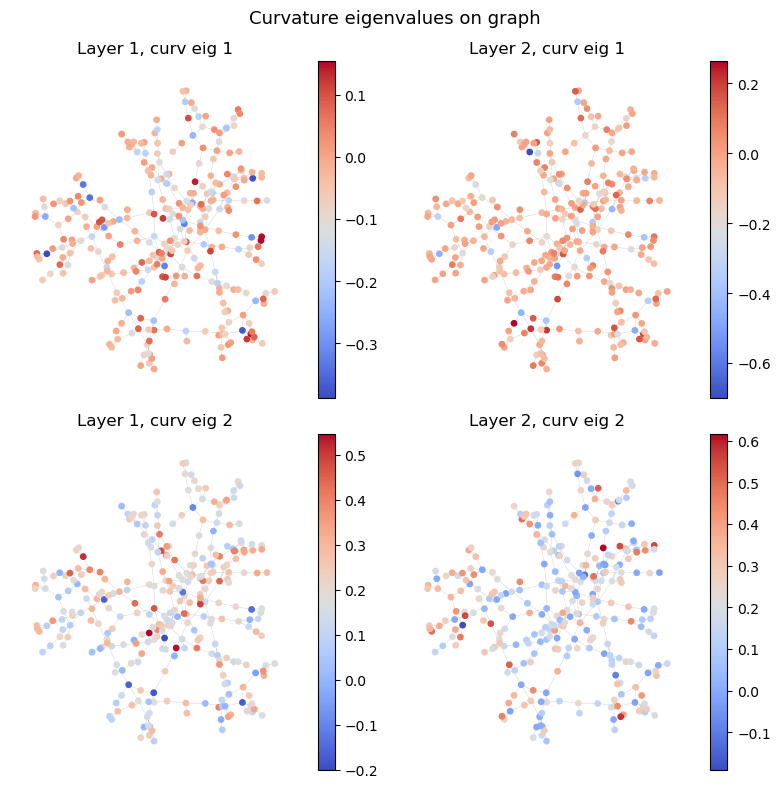

In [102]:
pos_use = nx.spring_layout(G, seed=42)
cmap = plt.cm.coolwarm

fig, axes = plt.subplots(d, layers, figsize=(4*layers, 4*d))
if d == 1: axes = axes.reshape(1, -1)
if layers == 1: axes = axes.reshape(-1, 1)

for k in range(d):
    for layer in range(layers):
        ax = axes[k, layer]
        vals = curv_eigs[layer][:, k]
        norm = plt.Normalize(vmin=vals.min(), vmax=vals.max())
        nx.draw_networkx_nodes(G, pos_use, ax=ax, nodelist=nodelist, node_size=15, node_color=cmap(norm(vals)))
        nx.draw_networkx_edges(G, pos_use, ax=ax, width=0.3, alpha=0.2)
        plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax)
        ax.set_title(f"Layer {layer+1}, curv eig {k+1}")
        ax.axis("off")

fig.suptitle("Curvature eigenvalues on graph", fontsize=13)
fig.tight_layout()
#fig.savefig(f"../results/images/{dataset}_curv_graph.pdf")
